In [1]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# GPU 설정 확인
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print("GPU Enabled")
    except RuntimeError as e:
        print(e)

# Sionna Import
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera, RadioMapSolver, PathSolver
from sionna.rt import scene as share_scene # 내장 씬 로드용

2025-11-24 19:59:09.584925: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764010749.593509 3915360 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764010749.596219 3915360 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-24 19:59:09.605987: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


GPU Enabled


In [2]:
# 1) Munich 씬 로드
scene = load_scene(share_scene.munich)

# 2) 씬 파라미터 설정
scene.frequency = 2.4e9 
scene.synthetic_array = True 

# 3) 안테나 배열 설정
scene.tx_array = PlanarArray(num_rows=1, num_cols=4,
                             vertical_spacing=0.5, horizontal_spacing=0.5,
                             pattern="iso", polarization="cross")

scene.rx_array = PlanarArray(num_rows=1, num_cols=2,
                             vertical_spacing=0.5, horizontal_spacing=0.5,
                             pattern="iso", polarization="cross")

# 4) 송신기(Tx) 배치
tx_pos = [100, 100, 30] 
tx = Transmitter(name="BaseStation",
                 position=tx_pos,
                 orientation=[0, 0, 0])
scene.add(tx)
tx.array = scene.tx_array 
tx.power_dbm = 40 

# 5) 카메라 설정 (수정된 부분)
# Camera 생성 시 name 인자를 제거하고, scene.add()도 하지 않습니다.
bird_cam = Camera(position=[0, 0, 1000], look_at=[0, 0, 0])
bird_cam.name = "bird_cam"  # 이름은 속성으로 따로 지정

# 주의: scene.add(bird_cam) 코드는 삭제합니다. 
# 카메라는 나중에 scene.render(camera=bird_cam, ...) 처럼 직접 사용합니다.

print("Scene loaded and configured.")

Scene loaded and configured.


Generating Radio Map (RSS)...
RSS Range: -170.00 dBm ~ -8.83 dBm


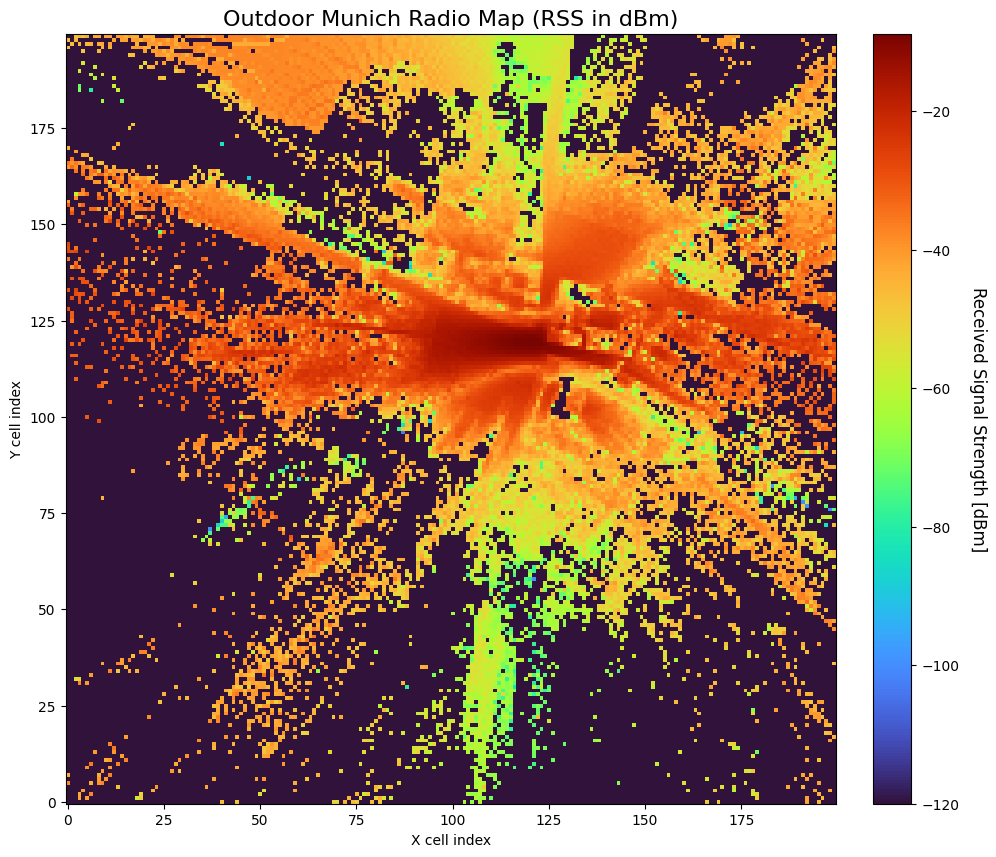

In [10]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import numpy as np

# 1. 송신기 위치 재설정 (전파가 닿도록 높이 조정)
scene.transmitters["BaseStation"].position = [100, 100, 60] # 높이 60m
scene.transmitters["BaseStation"].power_dbm = 60 # 출력 상향

# 2. Radio Map 계산 (Solver)
print("Generating Radio Map (RSS)...")
# num_samples 인자 제거, scene을 첫 번째 인자로 전달
rm = rm_solver(
    scene,
    max_depth=5,
    center=map_center,
    size=map_size,
    orientation=map_orientation,
    cell_size=cell_size
)

# 3. 데이터 추출 및 dBm 변환
# rm.rss shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, height, width]
# 불필요한 차원을 제거(squeeze)하여 2D 맵(height, width)으로 만듭니다.
rss_watt = np.squeeze(rm.rss.numpy()) 

# 0.0(수신불가) 값을 아주 작은 값(1e-20)으로 대체하여 log 계산 오류 방지
rss_dbm = 10 * np.log10(np.maximum(rss_watt, 1e-20)) + 30

# dBm 범위 계산 (시각화 스케일용)
vmin = np.min(rss_dbm)
vmax = np.max(rss_dbm)
# 최저값이 너무 낮으면(-170dBm 등) 색상이 뭉개지므로 -100dBm 정도로 하한선 설정
display_vmin = max(vmin, -120) 

print(f"RSS Range: {vmin:.2f} dBm ~ {vmax:.2f} dBm")

# 4. 2D 히트맵 시각화
plt.figure(figsize=(12, 10))

# 전파 강도(dBm)를 이미지로 표시
# origin='lower'는 맵의 좌표계(y축) 방향을 맞추기 위함입니다.
plt.imshow(rss_dbm, cmap='turbo', vmin=display_vmin, vmax=vmax, origin='lower')

# 컬러바(dBm 스케일) 추가
cbar = plt.colorbar(fraction=0.046, pad=0.04)
cbar.set_label('Received Signal Strength [dBm]', rotation=270, labelpad=20, fontsize=12)

plt.title("Outdoor Munich Radio Map (RSS in dBm)", fontsize=16)
plt.xlabel("X cell index")
plt.ylabel("Y cell index")
plt.show()

Rendering Radio Map over Munich Scene...


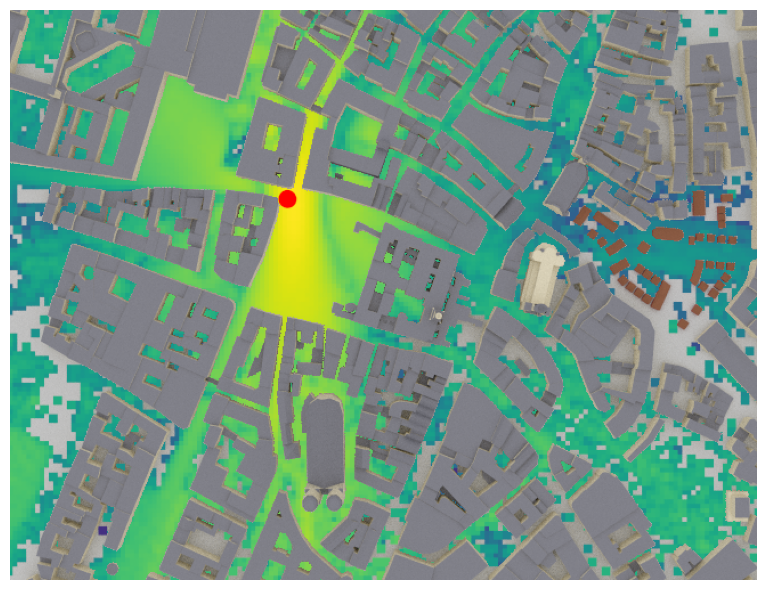

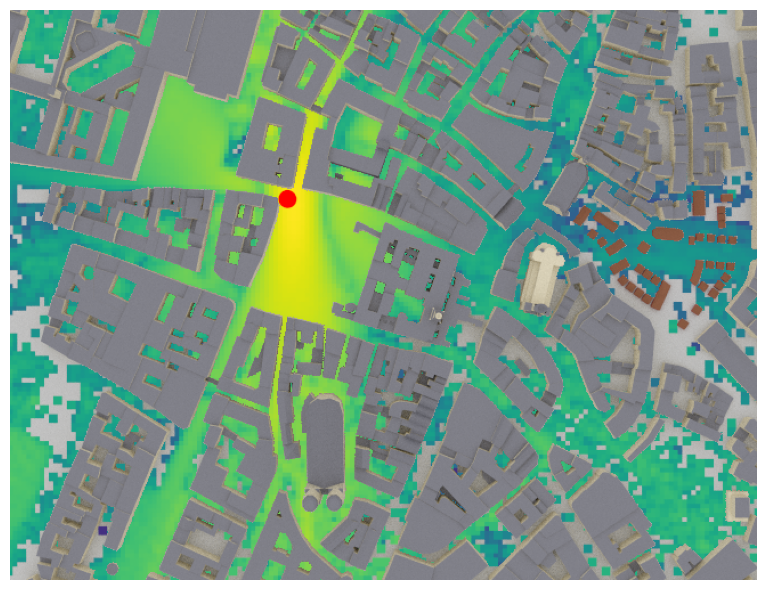

In [11]:
# 뮌헨 3D 씬(건물) 위에 Radio Map을 오버레이하여 시각화

# 1. 렌더링 실행
# camera: 위에서 내려다보는 시점 (bird_cam)
# radio_map: 계산된 커버리지 맵 (rm)
# show_devices: 송신기(기지국) 위치 표시
print("Rendering Radio Map over Munich Scene...")

# 변수에 할당하거나 .numpy()를 붙이지 않고, 함수를 직접 실행하면 그림이 출력됩니다.
scene.render(camera=bird_cam, radio_map=rm, show_devices=True)

Starting Ray Tracing with Smaller Dots...
Step 1 | Rx: [ 80.  120.    1.5] | Found Paths: 11


<Figure size 1000x1000 with 0 Axes>

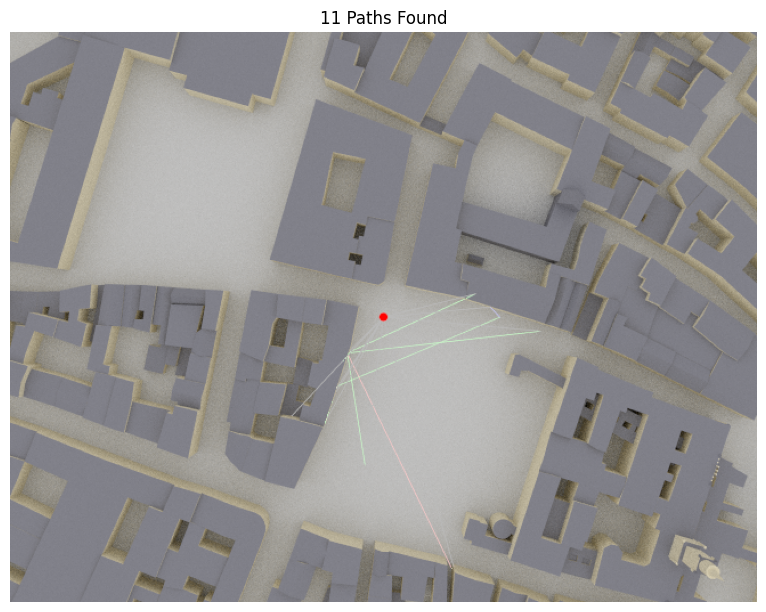

Step 2 | Rx: [ 80.  120.    1.5] | Found Paths: 10
Step 3 | Rx: [ 80.  120.    1.5] | Found Paths: 10
Step 4 | Rx: [ 80.  120.    1.5] | Found Paths: 11
Step 5 | Rx: [ 80.  120.    1.5] | Found Paths: 11
Simulation Complete.


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import drjit as dr
import gc
from sionna.rt import Receiver, PathSolver

# 1. 메모리 정리
gc.collect()
try:
    dr.flush_malloc_cache()
except:
    pass

# 2. 송신기 크기 줄이기 (기존 송신기 제거 후 재생성)
if "BaseStation" in scene.transmitters:
    scene.remove("BaseStation")

tx_pos = [100, 100, 80]
# [수정됨] display_radius=2.0 (송신기는 조금 더 잘 보이게 2m)
tx = Transmitter(name="BaseStation", position=tx_pos, orientation=[0, 0, 0], display_radius=2.0)
scene.add(tx)
tx.array = scene.tx_array
tx.power_dbm = 40

# 3. 시뮬레이션 설정
path_solver = PathSolver() 
cir_results = [] 

# 카메라 설정 (500m 고도 유지)
bird_cam = Camera(position=[100, 100, 500], look_at=[100, 100, 0])

print("Starting Ray Tracing with Smaller Dots...")

for i, pos in enumerate(traj_positions):
    # 메모리 정리
    gc.collect()
    try:
        dr.flush_malloc_cache()
    except:
        pass

    # 수신기 배치
    if "mobile_rx" in scene.receivers:
        scene.remove("mobile_rx")
    
    # [수정됨] display_radius=1.0 (수신기는 작게 1m)
    rx = Receiver(name="mobile_rx", position=pos, orientation=[0,0,0], display_radius=1.0)
    scene.add(rx)
    scene.get("BaseStation").look_at(rx)

    try:
        # Ray Tracing (이전 성공 설정 유지)
        paths = path_solver(
            scene, 
            max_depth=5,                 
            samples_per_src=200000,      
            max_num_paths_per_src=100,    
            diffuse_reflection=True,     
            specular_reflection=True,    
            los=True                     
        )
        
        # 데이터 처리
        a, tau = paths.cir(normalize_delays=True)
        try:
            cir_val = a.numpy()
        except AttributeError:
            cir_val = np.array(a)
        
        num_paths_found = cir_val.shape[-2] 
        cir_results.append(cir_val)

        print(f"Step {i+1} | Rx: {pos} | Found Paths: {num_paths_found}")
        
        if i == 0:
            plt.figure(figsize=(10,10))
            if num_paths_found > 0:
                scene.render(camera=bird_cam, paths=paths, show_devices=True)
                plt.title(f"{num_paths_found} Paths Found")
            else:
                scene.render(camera=bird_cam, show_devices=True)
                plt.title("No Paths Found")
            plt.show()
            
    except Exception as e:
        print(f"Error/OOM at step {i}: {e}")
        break

print("Simulation Complete.")

Plotting CIR (Magnitude) for the last receiver position...
Raw Data Shape - Gain: (2, 1, 1, 1, 1, 11, 1), Delay: (1, 1, 11)


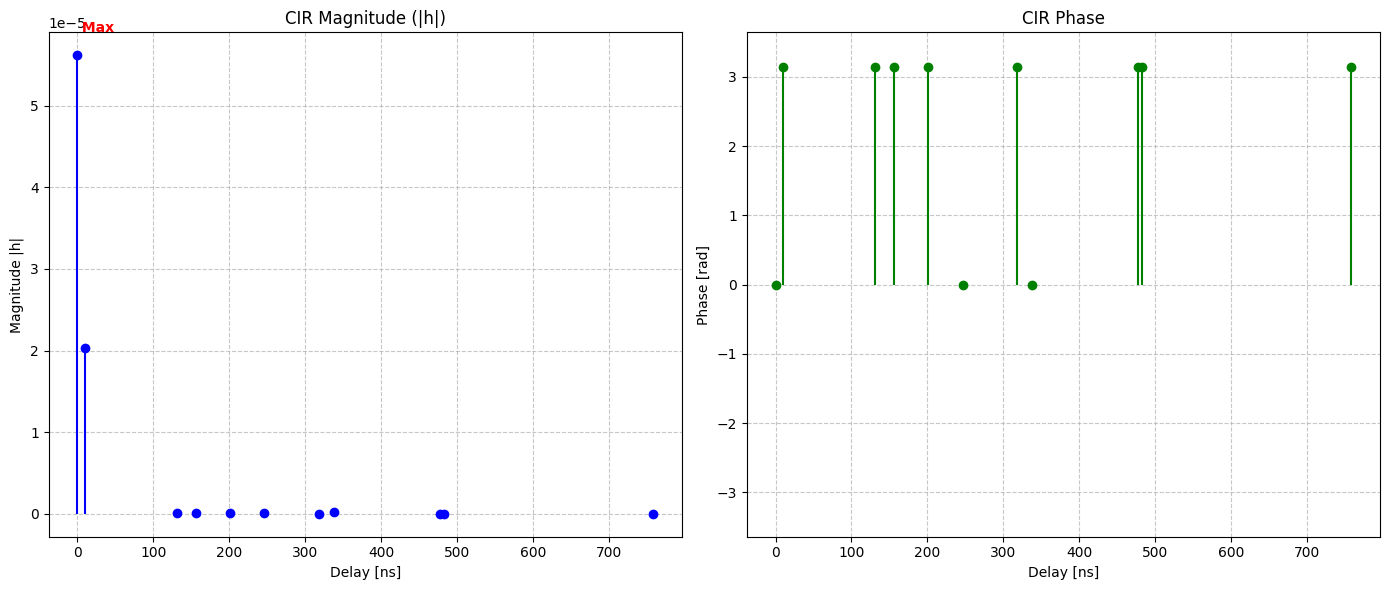


--- Path Details (Top 5 Strongest) ---
Delay:    0.00 ns | Mag: 0.000056 | Power: -55.01 dBm | Phase:  0.00 rad
Delay:    9.43 ns | Mag: 0.000020 | Power: -63.82 dBm | Phase:  3.14 rad
Delay:  338.11 ns | Mag: 0.000000 | Power: -105.53 dBm | Phase:  0.00 rad
Delay:  131.05 ns | Mag: 0.000000 | Power: -108.94 dBm | Phase:  3.14 rad
Delay:  246.43 ns | Mag: 0.000000 | Power: -113.44 dBm | Phase:  0.00 rad


In [14]:
import matplotlib.pyplot as plt
import numpy as np

# 6. CIR & Phase 그래프 그리기 (절댓값 버전)

print(f"Plotting CIR (Magnitude) for the last receiver position...")

# 1) CIR 데이터 추출
a, tau = paths.cir(normalize_delays=True)

# 2) 데이터 형 변환
if isinstance(a, (list, tuple)):
    a_np = np.array(a)
else:
    a_np = a.numpy()

if isinstance(tau, (list, tuple)):
    tau_np = np.array(tau)
else:
    tau_np = tau.numpy()

print(f"Raw Data Shape - Gain: {a_np.shape}, Delay: {tau_np.shape}")

# 3) 차원 맞추기
delay = tau_np.flatten()
num_paths = delay.shape[0]
gain_flat = a_np.flatten()

if gain_flat.size == num_paths:
    gain = gain_flat
elif gain_flat.size > num_paths:
    print(f"Warning: Gain has more elements ({gain_flat.size}) than Delay ({num_paths}). Using first {num_paths} elements.")
    gain = gain_flat[:num_paths]
else:
    print("Error: Gain has fewer elements than Delay. Cannot plot.")
    gain = np.zeros_like(delay)

# 4) 유효하지 않은 경로(0) 제거
valid_indices = np.where(np.abs(gain) > 1e-12)
gain = gain[valid_indices]
delay = delay[valid_indices] * 1e9 # s -> ns

# 5) Magnitude(절댓값) & Phase 계산
# [수정됨] 절댓값(|h|) 계산
magnitude = np.abs(gain) 

# (참고용) 텍스트 출력을 위해 dBm도 계산해둡니다.
power_watt = magnitude**2
power_dbm = 10 * np.log10(np.maximum(power_watt, 1e-20)) + 30
phase_rad = np.angle(gain)

# 6) 그래프 그리기
if len(delay) == 0:
    print("No valid paths found to plot (All powers are zero).")
else:
    plt.figure(figsize=(14, 6))

    # --- [그래프 1] CIR Magnitude (|h|) ---
    plt.subplot(1, 2, 1)
    # [수정됨] power_dbm 대신 magnitude 사용
    markerline, stemlines, baseline = plt.stem(delay, magnitude, linefmt='b-', markerfmt='bo', basefmt=" ")
    plt.setp(baseline, visible=False) 
    
    plt.title("CIR Magnitude (|h|)") # 제목 변경
    plt.xlabel("Delay [ns]")
    plt.ylabel("Magnitude |h|")      # Y축 라벨 변경
    plt.grid(True, linestyle='--', alpha=0.7)

    # 가장 강한 신호 표시
    if len(magnitude) > 0:
        max_idx = np.argmax(magnitude)
        # 텍스트 위치를 magnitude 기준으로 조금 위로 설정 (1.05배)
        plt.text(delay[max_idx], magnitude[max_idx] * 1.05, " Max", color='red', fontweight='bold')

    # --- [그래프 2] Phase Profile ---
    plt.subplot(1, 2, 2)
    plt.stem(delay, phase_rad, linefmt='g-', markerfmt='go', basefmt=" ")
    plt.title("CIR Phase")
    plt.xlabel("Delay [ns]")
    plt.ylabel("Phase [rad]")
    plt.ylim([-np.pi-0.5, np.pi+0.5])
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    # 상세 정보 출력 (여전히 dBm 정보는 유용하므로 함께 출력)
    print("\n--- Path Details (Top 5 Strongest) ---")
    sorted_indices = np.argsort(magnitude)[::-1] # 크기순 정렬
    for i in sorted_indices[:5]:
        print(f"Delay: {delay[i]:7.2f} ns | Mag: {magnitude[i]:.6f} | Power: {power_dbm[i]:6.2f} dBm | Phase: {phase_rad[i]:5.2f} rad")

Calculating Channel Frequency Response (CFR)...
Raw h_freq shape: (1, 1, 1, 1, 1, 64)
--- CFR Stats ---
Max Gain: -83.13 dB
Min Gain: -87.30 dB
Fading Depth: 4.16 dB


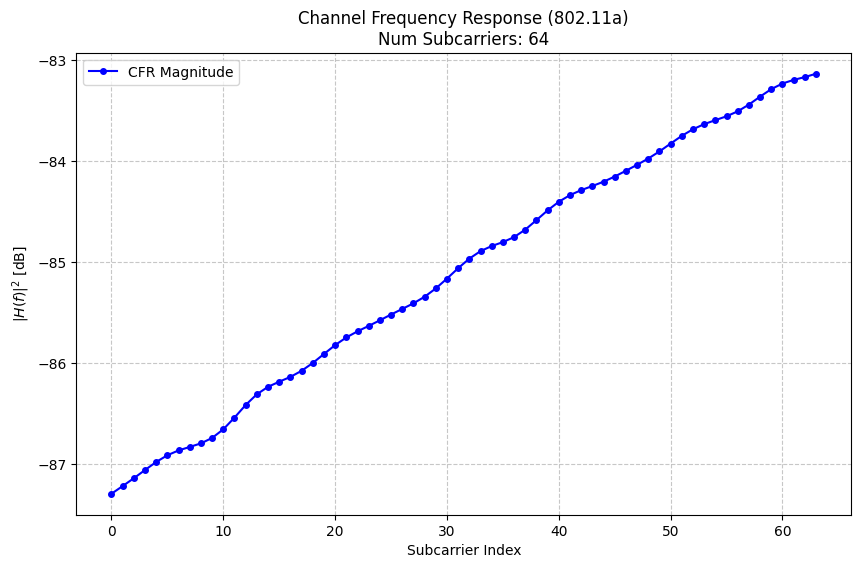

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from sionna.rt.utils import subcarrier_frequencies

# 7. OFDM 채널 주파수 응답 (CFR) 분석 (수정됨)

print("Calculating Channel Frequency Response (CFR)...")

# 1. OFDM 파라미터 설정
num_subcarriers = 64            
subcarrier_spacing = 312.5e3    

# 2. 주파수 그리드 생성
frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)

# 3. CFR 계산
# paths는 이전 단계에서 계산된 경로 객체입니다.
# [수정] out_type="numpy"를 추가하여 바로 Numpy 배열로 받습니다.
try:
    h_freq = paths.cfr(
        frequencies=frequencies,
        normalize=False,
        normalize_delays=True,
        out_type="numpy" 
    )
except TypeError:
    # out_type 옵션을 지원하지 않는 구버전일 경우
    h_freq = paths.cfr(
        frequencies=frequencies,
        normalize=False,
        normalize_delays=True
    )

# 4. 데이터 전처리 (Tuple/Tensor 처리)
# 반환값이 튜플인 경우 (h, ) 형태일 수 있으므로 꺼냅니다.
if isinstance(h_freq, tuple):
    h_freq = h_freq[0]

# 텐서인 경우 Numpy로 변환
if not isinstance(h_freq, np.ndarray):
    if hasattr(h_freq, 'numpy'):
        h_freq = h_freq.numpy()
    else:
        h_freq = np.array(h_freq)

print(f"Raw h_freq shape: {h_freq.shape}")

# 차원 축소: [batch, rx, rx_ant, tx, tx_ant, steps, subcarriers] -> [subcarriers]
# flatten()을 사용하여 1차원으로 폅니다.
h_freq_1d = h_freq.flatten()

# 데이터가 중복되어(배치 사이즈 등으로 인해) 서브캐리어 수보다 많으면 앞부분만 자릅니다.
if h_freq_1d.size > num_subcarriers:
    h_freq_1d = h_freq_1d[:num_subcarriers]

# 5. 전력(Power) 계산 및 dB 변환
power_linear = np.abs(h_freq_1d)**2
power_db = 10 * np.log10(np.maximum(power_linear, 1e-20)) 

# 6. 시각화
plt.figure(figsize=(10, 6))
plt.plot(power_db, marker='o', markersize=4, linestyle='-', color='b', label='CFR Magnitude')
plt.xlabel("Subcarrier Index")
plt.ylabel(r"$|H(f)|^2$ [dB]")
plt.title(f"Channel Frequency Response (802.11a)\nNum Subcarriers: {num_subcarriers}")
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend()

print(f"--- CFR Stats ---")
if len(power_db) > 0:
    print(f"Max Gain: {np.max(power_db):.2f} dB")
    print(f"Min Gain: {np.min(power_db):.2f} dB")
    print(f"Fading Depth: {np.max(power_db) - np.min(power_db):.2f} dB")

plt.show()

Calculating Discrete Channel Taps...
Channel Bandwidth: 20.00 MHz
Shape of taps:  (1, 1, 1, 1, 1, 107)


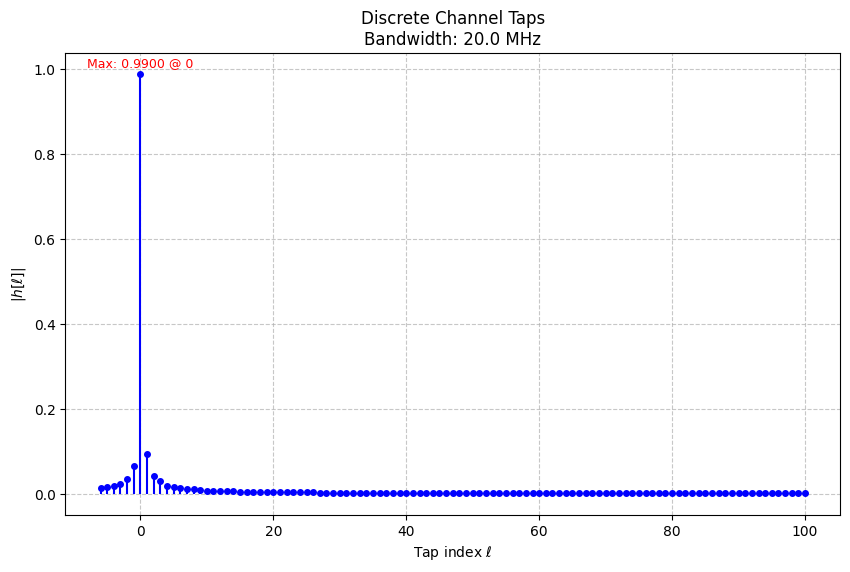

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# 8. Discrete Channel Taps 시각화

print("Calculating Discrete Channel Taps...")

# 1. 대역폭 계산
# OFDM 대역폭 = 부반송파 개수 * 부반송파 간격
ch_bandwidth = num_subcarriers * subcarrier_spacing
print(f"Channel Bandwidth: {ch_bandwidth / 1e6:.2f} MHz")

# 2. Taps 계산 (paths 객체 사용)
# l_min, l_max: 탭의 인덱스 범위 (음수 인덱스는 non-causal 성분이나 동기화 오차 등을 표현할 때 사용됨)
taps = paths.taps(
    bandwidth=ch_bandwidth,
    l_min=-6, 
    l_max=100,
    normalize=True,
    normalize_delays=True,
    out_type="numpy"
)

# Shape 확인: [batch, rx, rx_ant, tx, tx_ant, num_taps]
print("Shape of taps: ", taps.shape)

# 3. 데이터 전처리 (1차원으로 추출)
# 첫 번째 배치, 첫 번째 수신기/송신기/안테나의 탭 응답을 가져옵니다.
# taps[0, 0, 0, 0, 0, :] -> shape (107,)
h_taps = np.abs(taps)[0, 0, 0, 0, 0, :]
tap_indices = np.arange(-6, 101)

# 4. 시각화 (Stem Plot)
plt.figure(figsize=(10, 6))

# 줄기 그래프 그리기
markerline, stemlines, baseline = plt.stem(tap_indices, h_taps, basefmt=" ", linefmt='b-', markerfmt='bo')
plt.setp(markerline, markersize=4)

plt.xlabel(r"Tap index $\ell$")
plt.ylabel(r"|$h[\ell]|$")
plt.title(f"Discrete Channel Taps\nBandwidth: {ch_bandwidth/1e6:.1f} MHz")
plt.grid(True, which='both', linestyle='--', alpha=0.7)

# 가장 강한 탭 표시
max_idx = np.argmax(h_taps)
max_tap = tap_indices[max_idx]
max_val = h_taps[max_idx]
plt.text(max_tap, max_val + 0.01 * max_val, f"Max: {max_val:.4f} @ {max_tap}", 
         ha='center', va='bottom', color='red', fontsize=9)

plt.show()

Calculating Time-Varying Channel Frequency Response...
Original Shape of b_mob:  (1, 1, 1, 1, 100, 64)
Squeezed Shape (Time, Freq):  (100, 64)


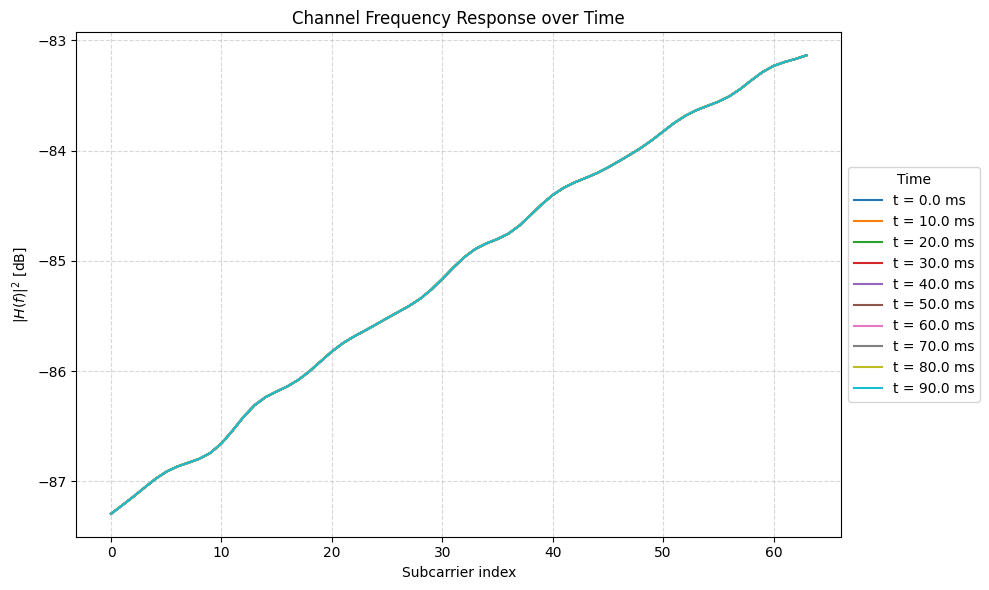

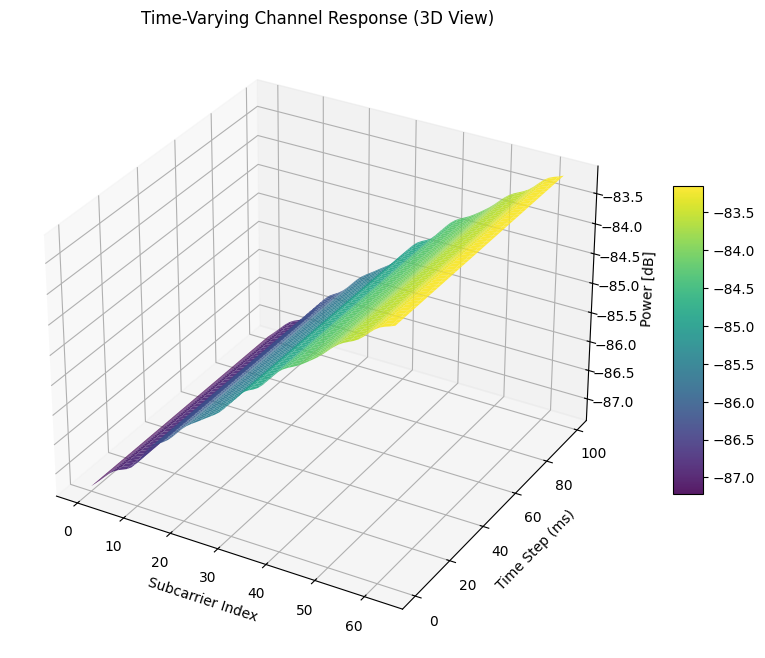


Generating Dataset...
Dataset Saved: csi_dataset.npz
Input X shape: (90, 10, 64) (Samples, Seq_Len, Subcarriers)
Label y shape: (90, 64) (Samples, Subcarriers)
File saved locally. Please check your directory.


In [17]:
import matplotlib.pyplot as plt
import numpy as np
from sionna.rt.utils import subcarrier_frequencies

# 7. Time-Variant CFR (시간에 따른 주파수 응답 변화) - 에러 수정 및 데이터셋 저장

print("Calculating Time-Varying Channel Frequency Response...")

# 1. 시뮬레이션 파라미터 설정 (이전 단계와 동일 가정)
num_subcarriers = 64
subcarrier_spacing = 312.5e3
frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)
sampling_frequency = 1000.0  # 1kHz
num_time_steps = 100         # 100ms

# 2. CFR 계산
# out_type="numpy"로 바로 Numpy 배열 획득 시도
try:
    b_mob = paths.cfr(
        frequencies=frequencies,
        sampling_frequency=sampling_frequency,
        num_time_steps=num_time_steps,
        out_type="numpy"
    )
except TypeError:
    # 구버전 호환성
    b_mob = paths.cfr(
        frequencies=frequencies,
        sampling_frequency=sampling_frequency,
        num_time_steps=num_time_steps
    )
    if isinstance(b_mob, tuple): b_mob = b_mob[0]
    if hasattr(b_mob, 'numpy'): b_mob = b_mob.numpy()
    else: b_mob = np.array(b_mob)

print("Original Shape of b_mob: ", b_mob.shape)

# [핵심 수정] 불필요한 차원 제거 (Squeeze)
# (1, 1, 1, 1, 100, 64) -> (100, 64) 로 변환
# 이렇게 하면 [time_steps, subcarriers] 형태가 됩니다.
cfr_2d = np.squeeze(b_mob)

print("Squeezed Shape (Time, Freq): ", cfr_2d.shape)


# 3. 2D 시각화: 시간 흐름에 따른 주파수 응답 스냅샷
plt.figure(figsize=(10, 6))

# Power [dB] 계산
cfr_power_db = 10 * np.log10(np.abs(cfr_2d)**2 + 1e-20)

# 10 스텝 간격으로 그리기
for idx in range(0, num_time_steps, 10):
    time_ms = idx / sampling_frequency * 1000
    plt.plot(cfr_power_db[idx, :], label=f't = {time_ms:.1f} ms')

plt.xlabel("Subcarrier index")
plt.ylabel(r"$|H(f)|^2$ [dB]")
plt.title("Channel Frequency Response over Time")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Time")
plt.tight_layout()
plt.show()


# 4. 3D Surface 시각화 (전체적인 변화 확인)
try:
    from mpl_toolkits.mplot3d import Axes3D
    
    X, Y = np.meshgrid(np.arange(num_subcarriers), np.arange(num_time_steps))
    
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # (Time, Freq) 2D 배열을 3D 표면으로 플롯
    surf = ax.plot_surface(X, Y, cfr_power_db, cmap='viridis', edgecolor='none', alpha=0.9)
    
    ax.set_xlabel('Subcarrier Index')
    ax.set_ylabel('Time Step (ms)')
    ax.set_zlabel('Power [dB]')
    ax.set_title('Time-Varying Channel Response (3D View)')
    fig.colorbar(surf, shrink=0.5, aspect=10)
    plt.show()
except Exception as e:
    print(f"3D plot skipped: {e}")


# 5. 데이터셋 생성 및 저장 (Sliding Window)
# 과거 10개의 CSI를 보고 미래 1개의 CSI를 예측하는 데이터셋 생성
print("\nGenerating Dataset...")

seq_len = 10       # 과거 10ms
pred_horizon = 1   # 미래 1ms 예측

X_data, y_data = [], []
# 슬라이딩 윈도우
for t in range(len(cfr_2d) - seq_len - pred_horizon + 1):
    X_data.append(cfr_2d[t : t + seq_len])                # 입력: (10, 64)
    y_data.append(cfr_2d[t + seq_len + pred_horizon - 1]) # 정답: (64,)

X_data = np.stack(X_data)
y_data = np.stack(y_data)

# 파일 저장
np.savez("csi_dataset.npz", data=X_data.astype(np.complex64), labels=y_data.astype(np.complex64))
print(f"Dataset Saved: csi_dataset.npz")
print(f"Input X shape: {X_data.shape} (Samples, Seq_Len, Subcarriers)")
print(f"Label y shape: {y_data.shape} (Samples, Subcarriers)")

# 다운로드 (Colab용)
try:
    from google.colab import files
    files.download("csi_dataset.npz")
except ImportError:
    print("File saved locally. Please check your directory.")

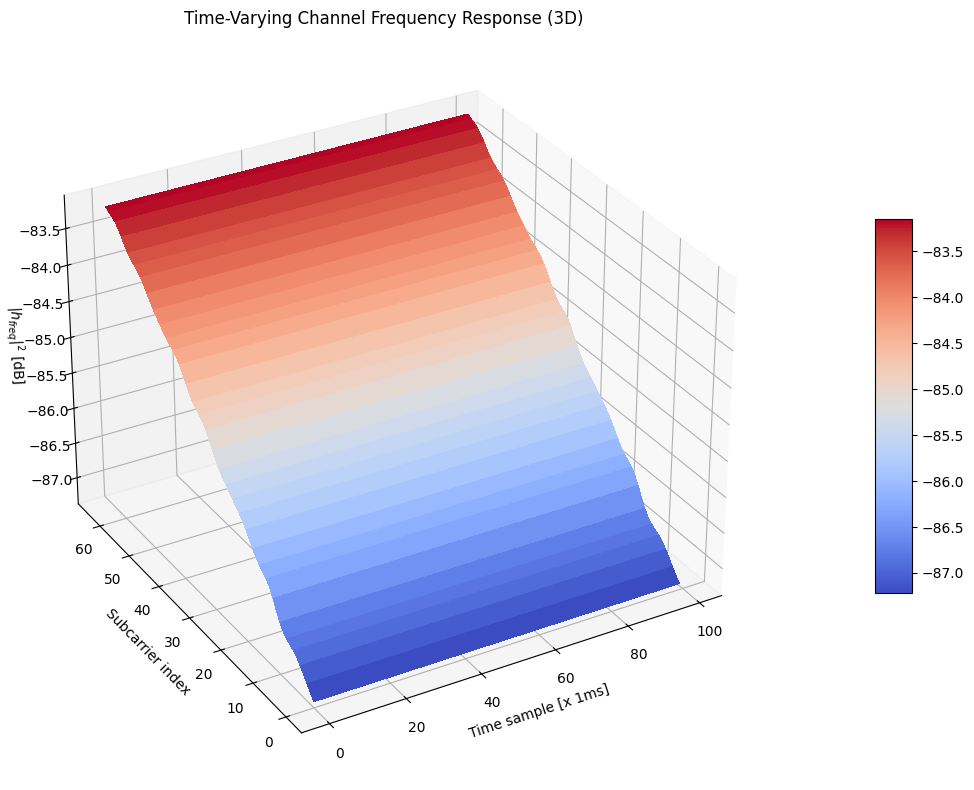

In [18]:
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np

# 1. 3D 플롯을 위한 데이터 준비
# b_mob shape: (1, 1, 1, 1, 100, 64) -> (Batch, Rx, Tx_batch, Tx, Time, Subcarrier)
num_time_steps = b_mob.shape[4]
num_subcarriers = b_mob.shape[5]

# X, Y 축 격자 생성 (Time, Subcarrier)
X = np.arange(0, num_time_steps)     # 시간 축 (0 ~ 99)
Y = np.arange(0, num_subcarriers)    # 주파수(서브캐리어) 축 (0 ~ 63)
X, Y = np.meshgrid(X, Y)             # 2D 그리드 생성 (shape: 64x100)

# Z 축 데이터 (CFR Power in dB)
# Z 배열 초기화: (Subcarrier, Time) 크기인 (64, 100)
Z = np.zeros((num_subcarriers, num_time_steps))

# 각 시간 스텝별로 모든 서브캐리어의 전력(dB) 계산하여 채움
for t in range(num_time_steps):
    # b_mob[0,0,0,0,t,:] : t 시점의 64개 서브캐리어 복소 이득
    power = np.abs(b_mob[0, 0, 0, 0, t, :]) ** 2
    Z[:, t] = 10 * np.log10(power + 1e-20)  # log(0) 방지용 엡실론 추가

# 2. 3D Surface Plot 그리기
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# 서피스 플롯 생성
surf = ax.plot_surface(X, Y, Z,
                       cmap=cm.coolwarm,
                       linewidth=0,
                       antialiased=False)

# 축 레이블 설정
ax.set_xlabel("Time sample [x 1ms]")
ax.set_ylabel("Subcarrier index")
ax.set_zlabel(r"$|h_{freq}|^2$ [dB]")
ax.set_title("Time-Varying Channel Frequency Response (3D)")

# 컬러바 추가
fig.colorbar(surf, shrink=0.5, aspect=10, pad=0.1)

# 시각화 각도 조정 (선택 사항)
ax.view_init(elev=30, azim=-120)

plt.tight_layout()
plt.show()